# Project Summary

Uber Technologies Inc. is a global ride-hailing platform that connects riders with drivers through a real-time, data-driven ecosystem. This project focuses on analyzing the demand and supply gap within Uber’s operations by examining trip request data, driver availability,time-based patterns,and location trends.The objective is to identify key factors contributing to unmet demand, such as peak hours, driver shortages,and cancellation patterns, and to derive actionable insights that can help optimize resource allocation and improve customer experience. Using data analytics techniques, the project aims to support strategic decision-making by highlighting inefficiencies in the current system and recommending solutions to balance supply with fluctuating rider demand.

# GitHub Link

In [ ]:
https://github.com/OlentiusHembrom/Uber_Data_Analysis.git

# Problem Statement

A dataset on which the Uber Demand Gap will be analyzed and also problems will be solved through EDA Operations.

Business Objectives :

The following are the business objective for this projects - 

1. To find the reason of cancellation of cab riders by drivers.
2. To find the solution to increase the transparency of cab ride fairs.
3. To find the permanent solution to customer problems so that to increase customer engagement and customer satisfaction rate.
4. To find various method to increase customer engagement to use this app over other apps and ulti,ately increase profit for the organization.
5. To find solution to increase safety of cab riders specially in night time.                                                                                                                        

# 1. Know Your Data

In [4]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import plotly.express as px
import random
from wordcloud import WordCloud
import ast
import statsmodels as stat
import geopandas as geo
import missingno as ms



# Dataset Loading

In [5]:
md = pd.read_csv("Uber Request Data.csv")

# Dataset First View

In [63]:
md.head()  # automatically it shows the first five detail, if needed more than five then we have to put our parameters like md.head(6) for first six details and md.head(10) for first ten details

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,11/07/16 11:51,11/07/16 13:00
1,867,Airport,1.0,Trip Completed,11/07/16 17:57,11/07/16 18:47
2,1807,City,1.0,Trip Completed,12/07/16 9:17,12/07/16 9:58
3,2532,Airport,1.0,Trip Completed,12/07/16 21:08,12/07/16 22:03
4,3112,City,1.0,Trip Completed,13/07/16 8:33,13/07/16 9:25
5,3879,Airport,1.0,Trip Completed,13/07/16 21:57,13/07/16 22:28
6,4270,Airport,1.0,Trip Completed,14/07/16 6:15,14/07/16 7:13
7,5510,Airport,1.0,Trip Completed,15/07/16 5:11,15/07/16 6:07
8,6248,City,1.0,Trip Completed,15/07/16 17:57,15/07/16 18:50
9,267,City,2.0,Trip Completed,11/07/16 6:46,11/07/16 7:25


# Dataset Bottom View

In [6]:
md.tail()  # same as with bottom view

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
6740,6745,City,NaN,No Cars Available,15/07/16 23:49,NaN
6741,6752,Airport,NaN,No Cars Available,15/07/16 23:50,NaN
6742,6751,City,NaN,No Cars Available,15/07/16 23:52,NaN
6743,6754,City,NaN,No Cars Available,15/07/16 23:54,NaN
6744,6753,Airport,NaN,No Cars Available,15/07/16 23:55,NaN


# Dataset Rows & Columns Count

In [31]:
md.shape  # in this dataset we have 6745 rows and 6 columns

(6745, 6)

# Dataset Information

In [65]:
md.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Request id         6745 non-null   int64  
 1   Pickup point       6745 non-null   object 
 2   Driver id          4095 non-null   float64
 3   Status             6745 non-null   object 
 4   Request timestamp  6745 non-null   object 
 5   Drop timestamp     2831 non-null   object 
dtypes: float64(1), int64(1), object(4)
memory usage: 316.3+ KB


# Duplicate Values

In [37]:
duplicates = md.duplicated(keep = False)        # checking for duplicate values
duplicate_count = duplicates.value_counts()      # counting the duplicate values
print(duplicate_count)

False    6745
Name: count, dtype: int64


# Missing Values / Null Values

In [38]:
md.isnull().sum()   # Missing Values Count

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

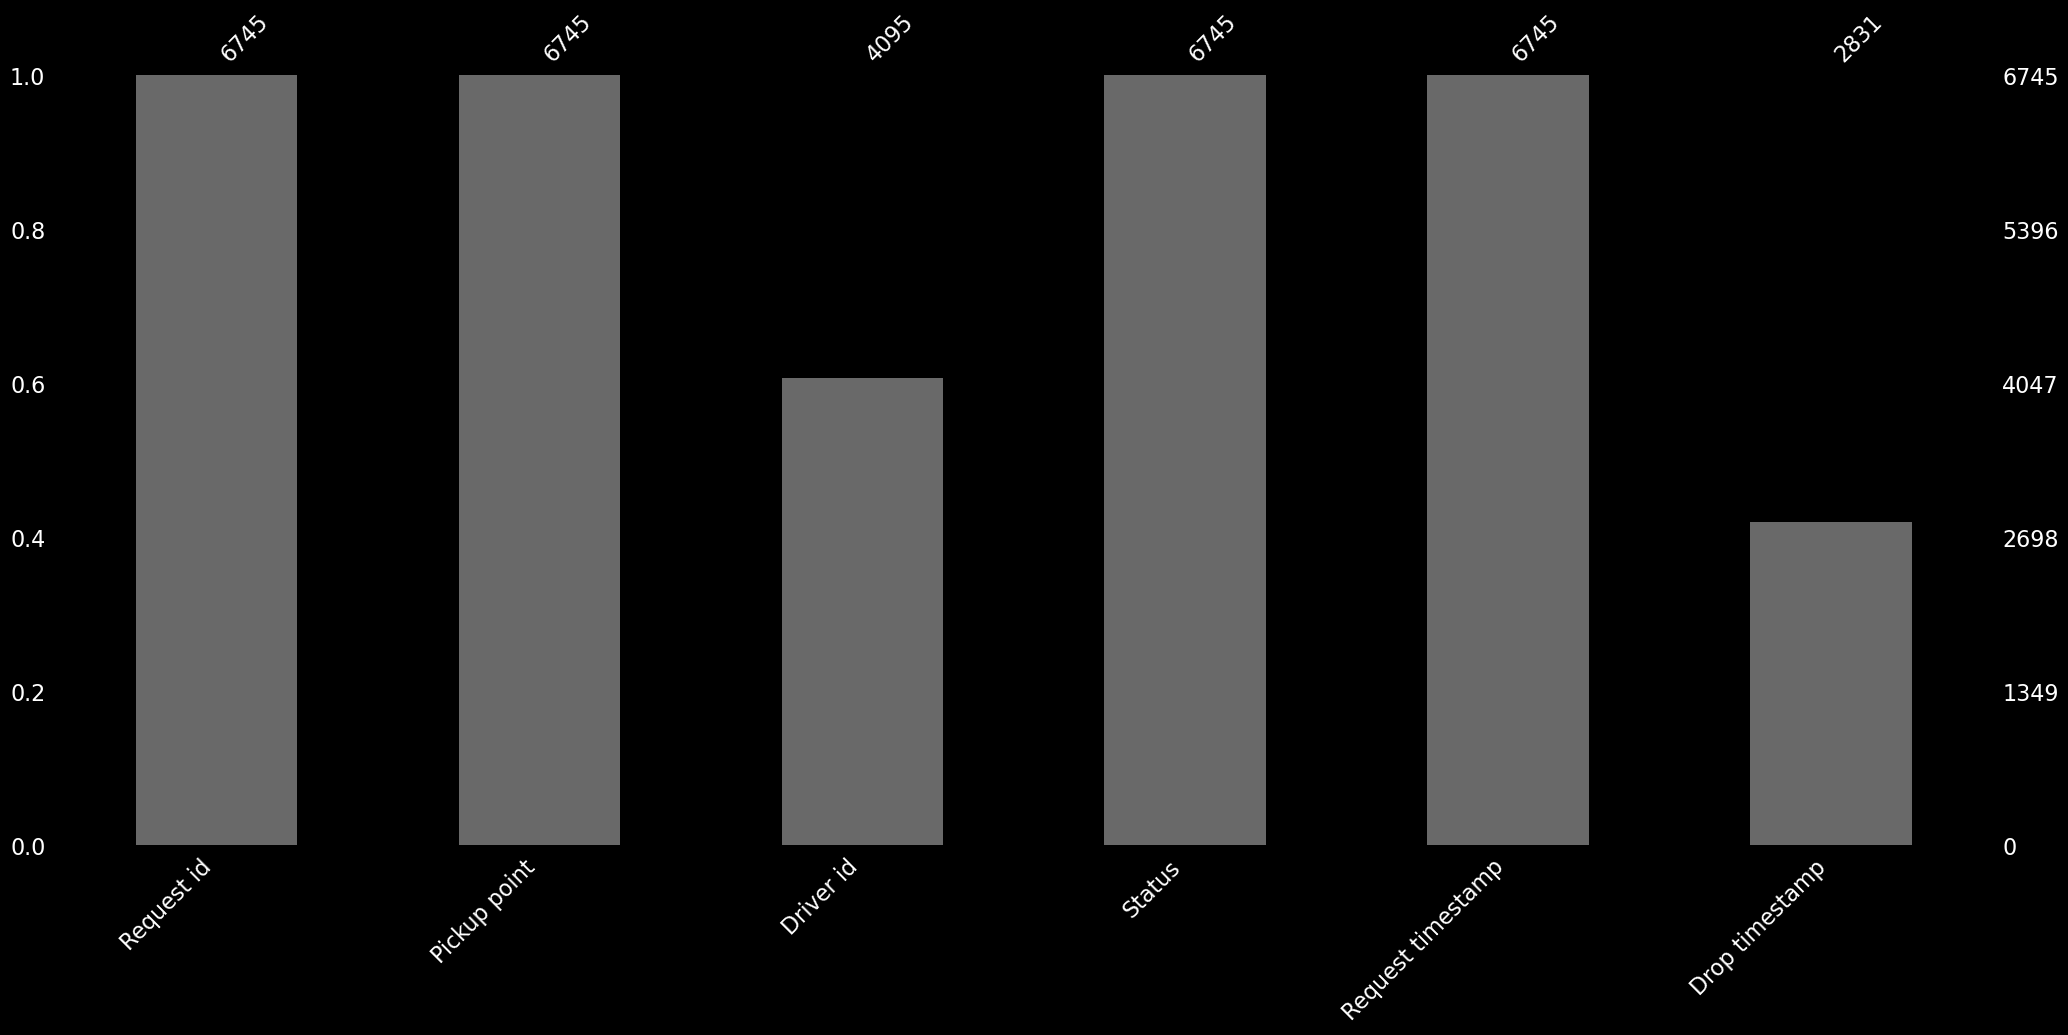

In [71]:
# Visualizing the missing values
ms.bar(md)
plt.show()

### What did you know about your dataset ?
 
#### following are the major points about the dataset :
     1. The dataset contains 6745 rows and 6 columns.
     2. There are no duplicate values in the dataset.
    
    

#### following 2 columns are having missing values :
     1. Driver Id - 2650  
     2. Drop Timestamp - 3914
    
    


# 2. Understand Your Variables

In [73]:
md.columns   # shows dataset column names

Index(['Request id', 'Pickup point', 'Driver id', 'Status',
       'Request timestamp', 'Drop timestamp'],
      dtype='object')

In [7]:
md.describe()

,Request id,Driver id
count,6745.000000,4095.000000
mean,3384.644922,149.501343
std,1955.099667,86.051994
min,1.000000,1.000000
25%,1691.000000,75.000000
50%,3387.000000,149.000000
75%,5080.000000,224.000000
max,6766.000000,300.000000


## Variables Description

### The followings are the variables with their description :

### Column Name --------------------------------------------- Description

1. Request id -------------------------------------------------- Customer unique id, who requested for the cab service through app.
2. Pickup point ------------------------------------------------ Location where cab driver will pickup the customer.
3. Driver id --------------------------------------------------- Unique id of driver who drives the cab.
4. Status ------------------------------------------------------ Information about the trip, whether it is completed, cancelled, or no cabs available.
5. Request timestamp ------------------------------------------- Request time and date when the customer requested for the cab service.
6. Drop timestamp ---------------------------------------------- Drop time and date when the customer is dropped to their respective destination.                                                                                                                  

## Check unique values for each variables

In [8]:
for x in md.columns :
    print(f" {x} - {md[x].nunique()}")      # nunique is the function to get the unique value of the column

 Request id - 6745
 Pickup point - 2
 Driver id - 300
 Status - 3
 Request timestamp - 4016
 Drop timestamp - 2282


# 3. Data Wrangling

### Data Wrangling code

In [9]:
# dataset analysis ready code
# checking for the null values in the dataset

md.isnull().sum()

Request id              0
Pickup point            0
Driver id            2650
Status                  0
Request timestamp       0
Drop timestamp       3914
dtype: int64

In [10]:
md.fillna({"Driver id" : "Not Available"}, inplace = True)   # filling the null values in the Driver id column with Not Available

In [13]:
md.fillna({"Drop timestamp" : "Not Available"}, inplace = True)  # filling the null values in the Drop timestamp column with Not Available

In [14]:
# after filling, rechecking the null values whether it is still present or removed

md.isnull().sum()

Request id           0
Pickup point         0
Driver id            0
Status               0
Request timestamp    0
Drop timestamp       0
dtype: int64

## what all manipulations have you done and insights you found ?

The following manipulation are done to the dataset :

1. As there were no duplicates in the dataset, so, no issue of removing it.
2. There were total 2 columns having missing values which replaced with Not Available value.

   Missing Values containing columns were :

       1. Driver id ----- 2650
       2. Drop timestamp ----3914

# 4. Data Visualization, Storytelling & Experimenting with charts : Understand the relation between Variables

## Chart 1

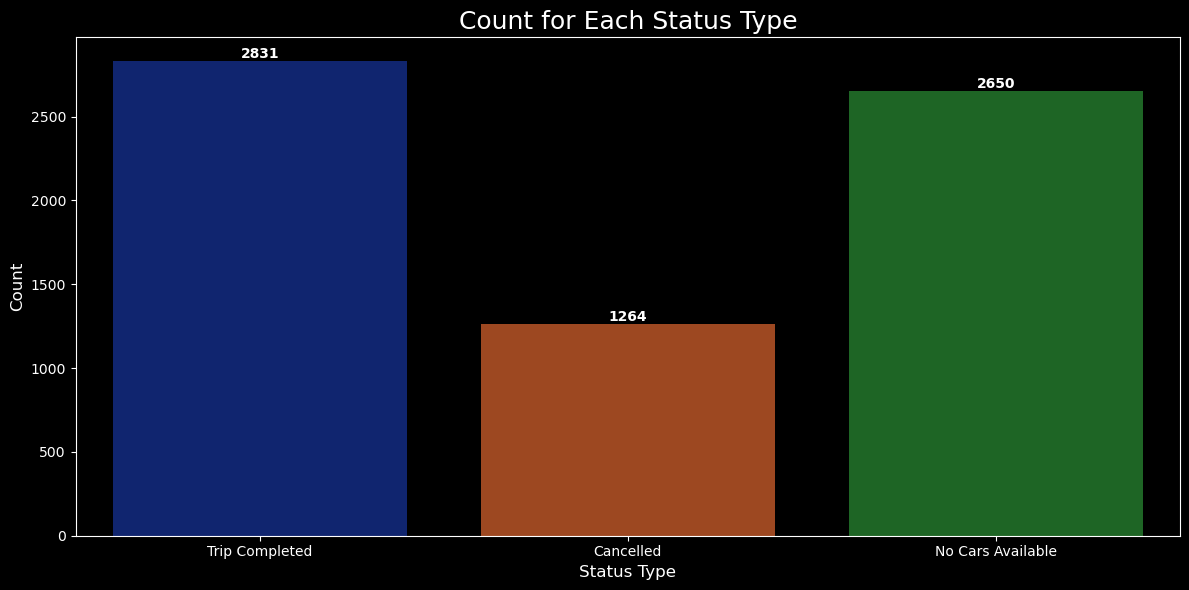

In [11]:
# Chart Visualization Codes
plt.style.use("dark_background")
md.columns = md.columns.str.strip()   # removing unnecessary spaces in the columns of the dataset
plt.figure(figsize = (12,6))   # plotting the figure / graph
ax = sns.countplot(x = "Status", data = md, hue = "Status", palette = "dark", legend = 0)
plt.title("Count for Each Status Type", fontsize = 18)   # heading of the graph 
plt.xlabel("Status Type", fontsize = 12)   # title on x axis  
plt.ylabel("Count", fontsize = 12)    # title on y axis
for p in ax.patches :
    count = int(p.get_height())
    x = p.get_x() + p.get_width() /2
    y = p.get_height()
    ax.annotate (  
       str(count),
       (x,y),
       ha = "center",
       va = "bottom",
       fontsize = 10,
       color = "white",
       fontweight = "bold"
   )

plt.grid(False)
plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart?
The above bar plot gives clear count for status type.

#### 2. What are are the insights found from the chart ?
The following are the insights for the above bar chart :
  1. Trip Completion status which is 2831 got the highest count in the chart.
  2. No Cars Available status which is 2650 got the second highest count in the chart.
  3. With 1264, Cancelled status got the lowest count in the chart.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that maximum cars have completed their trip but almost equal number of cars have not completed trip as they were not
available at the moment,which means uber has to increase its car numbers so as to increase availability of cars for customers and increase profit 
for the organization.

## Chart - 2

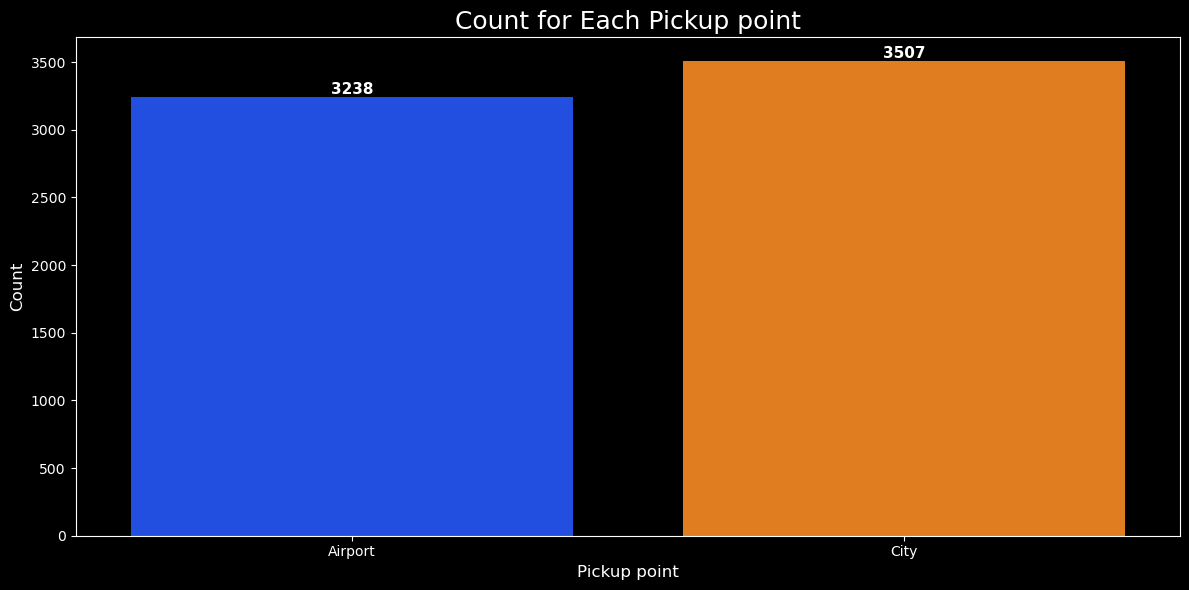

In [10]:
# Chart Visualization Codes
plt.style.use("dark_background")
md.columns = md.columns.str.strip()   # to remove unnecessary spaces in the particular column 
plt.figure(figsize = (12,6))    # plotting the figure / chart
ax = sns.countplot(x = "Pickup point", data = md, hue = "Pickup point", palette = "bright", legend = 0)
plt.title("Count for Each Pickup point", fontsize = 18)
plt.xlabel("Pickup point", fontsize = 12)
plt.ylabel("Count", fontsize = 12)
for p in ax.patches :
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = "center",
        va = "bottom",
        fontsize = 11,
        color = "white",
        fontweight = "bold"
    )

plt.grid(False)
plt.tight_layout()
plt.show()


#### 1. Why did you pick the specific chart ?

The above bar plot gives clear count for pickup point.

#### 2. What are the insights found from the chart ?

The following are the insights for the above bar plot :

1. City pickup point got the highest count with 3507.
2. Airport pickup point got the lowest count with 3238.

#### 3. Will the gained insughts help creating a positive business impact ?

Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that people often prefer Uber services inside city commute rather than airport commute.Which means company can do campaigns and offer some discounts on premium Uber black service,if customer books it from airport to ultimately increase profits for the company.

## Chart - 3

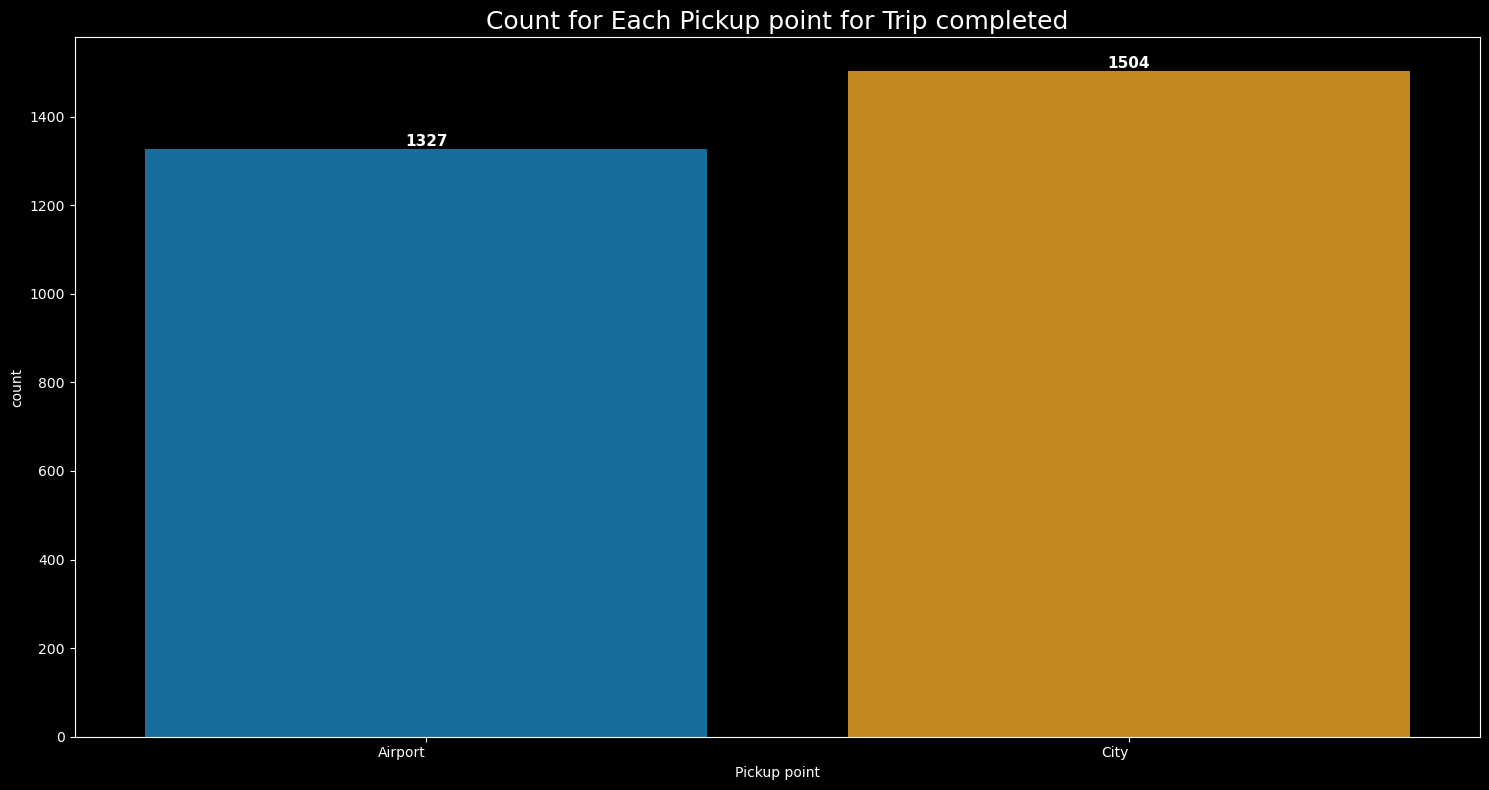

In [24]:
# Chart Visualization Codes
plt.style.use("dark_background")
trip_c = md[md.Status == "Trip Completed"].groupby("Pickup point")["Pickup point"].count()
trip_c1 = pd.DataFrame(trip_c)

# Rename the count column
trip_c1.rename(columns = {"Pickup point" : "count"}, inplace = True)
trip_c1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize = (15,8))
ax = sns.barplot(data = trip_c1, x = "Pickup point", y = "count", hue = "Pickup point", palette = "colorblind", legend = 0)

# Rotate x - axis labels for better readability
plt.xticks(rotation = 0, ha = "right")
plt.xlabel("Pickup point")
plt.ylabel("count")
plt.title("Count for Each Pickup point for Trip completed", fontsize = 18)
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = "center",
        va = "bottom",
        fontsize = 11,
        color = "white",
        fontweight = "bold"
    )

plt.grid(False)
plt.tight_layout()
plt.show()


#### 1. Why did you pick the specific chart ?

Bar plot gives the clear count when using group by functions.

#### 2. What are the insights found from the chart ?
The following are the insights for the above bar plot :

1. In city, Trip Completed Status got the highest count with 1504 trip completed.
2. In airport, Trip Completed Status got the lowest count with 1327 trip completed.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

As per the above insights, it shows that almost equal number of count is there for trip completion status for both pickup poin which is great positive sign.But, company can improve a little bit for airport pickup point to increase overall customer satisfaction and points.

## Chart - 4

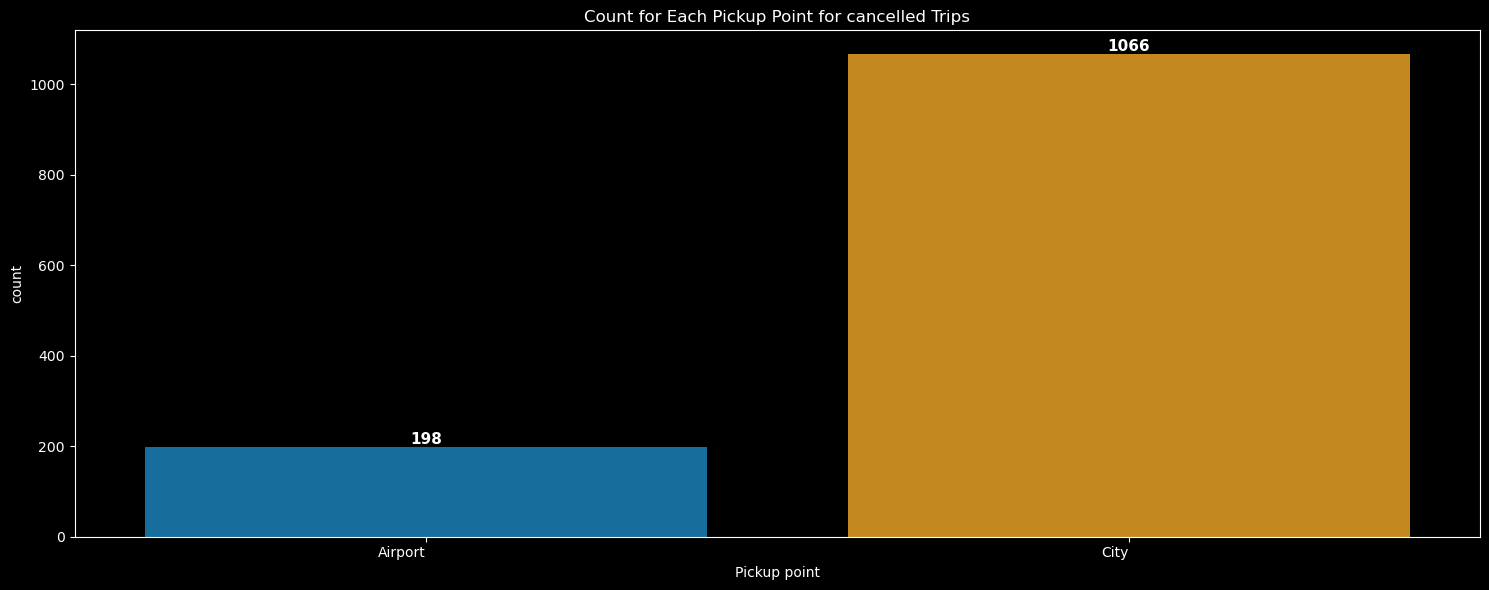

In [27]:
# Chart Visualization Codes
plt.style.use("dark_background")
cancel = md[md.Status == "Cancelled"].groupby("Pickup point")["Pickup point"].count()
cancel_1 = pd.DataFrame(cancel)

# Rename the count column
cancel_1.rename(columns = {"Pickup point" : "count"}, inplace = True)
cancel_1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize = (15,6))  # adjust figure size
ax = sns.barplot(data = cancel_1, x = "Pickup point", y = "count", hue = "Pickup point", palette = "colorblind", legend = 0)

# Rotate x-axis labels for better readability
plt.xticks(rotation = 0, ha = "right")
plt.xlabel("Pickup point")
plt.ylabel("count")
plt.title("Count for Each Pickup Point for cancelled Trips")
for p in ax.patches :
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = "center",
        va = "bottom",
        fontsize = 11,
        color = "white",
        fontweight = "bold"
    )

plt.grid(False)
plt.tight_layout()
plt.show()


                        

####  1. Why did you pick the specific chart ?
Bar plot gives clear count when using group by function.

#### 2. What are the insights found from the chart ?
The following are the insights for the above bar plot :

1. In city, Cancelled Trips Status got highest count with 1066 cancellation trips.
2. In airport, Cancelled trips Status got lowest count with 198 cancellation trips.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows a very negative aspect, as we know already that the count for pickup point in city is greater than airport and here we can see that the maximum count of cancelled trips is for city pickup point which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating, so as to avoid this, company should monitor on drivers who are cancelling rides inside city commute, so as to increase future customer engagement and overall company reputation.

## Chart - 5

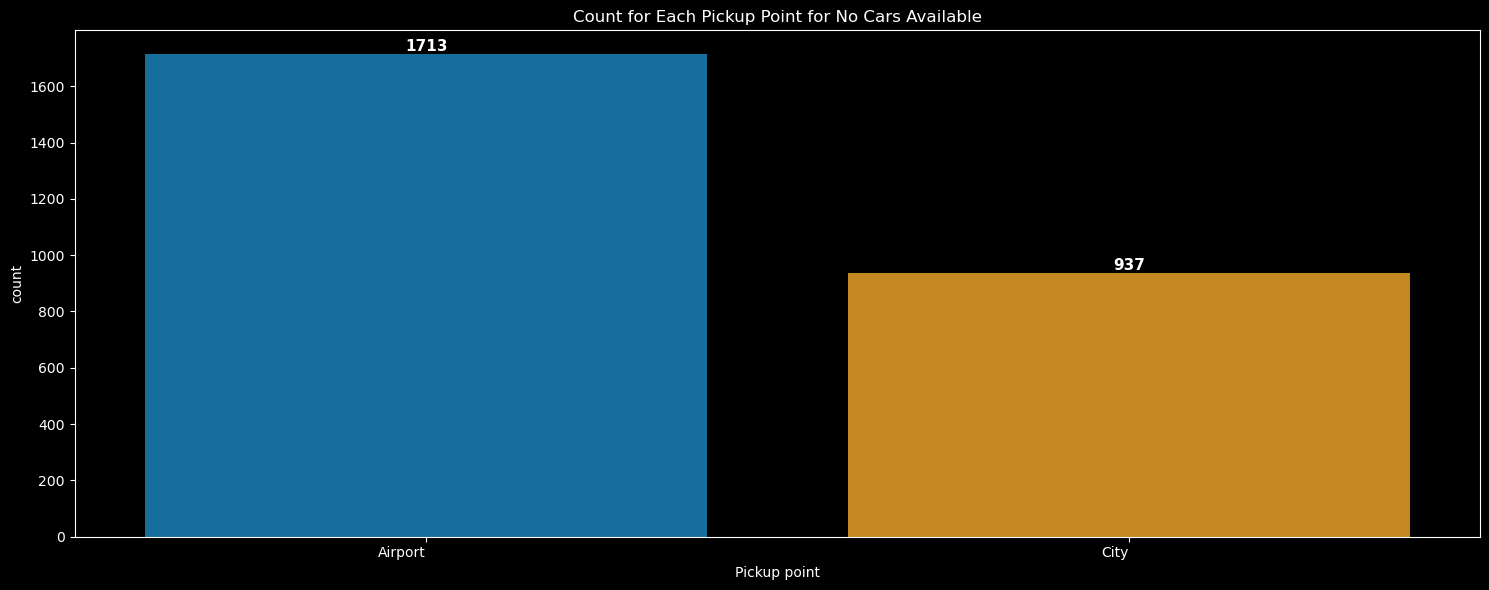

In [31]:
# Chart Visualization Codes
plt.style.use("dark_background")
nocars = md[md.Status == "No Cars Available"].groupby("Pickup point") ["Pickup point"].count()
nocars_1 = pd.DataFrame(nocars)

#Rename the count column
nocars_1.rename(columns = {"Pickup point" : "count"}, inplace = True)
nocars_1.reset_index(inplace = True)

# Create a bar plot
plt.figure(figsize = (15,6))  # Adjust figure size
ax = sns.barplot(data = nocars_1, x = "Pickup point", y = "count", hue = "Pickup point", palette = "colorblind", legend = 0)

# Rotate x-axis labels for better readability
plt.xticks(rotation = 0, ha = "right")
plt.xlabel("Pickup point")
plt.ylabel("count")
plt.title("Count for Each Pickup Point for No Cars Available")
for p in ax.patches:
    count = int(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(
        str(count),
        (x,y),
        ha = "center",
        va = "bottom",
        fontsize = 11,
        color = "white",
        fontweight = "bold"
    )

plt.grid(False)
plt.tight_layout()
plt.show()
    

#### 1. Why did you pick the specific chart ?
Bar plot gives clear count when using group by function.

#### 2. What arte the insights found from the chart ?
The following are the insights for the above bar plot :

1. In airport, No Cars Available Status got the highest count with 1713.
2. In city, No Cars Available status got the lowest count with 937.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that maximum cars are not available at airport pickup point where the most of the business comes for any cab service company, so if Uber wants to increase its profits it should provide more number of cars at airport, so as not to miss the opportunity of earning and retaining frequent customers who commute through airport and use cab services.

## Chart - 6

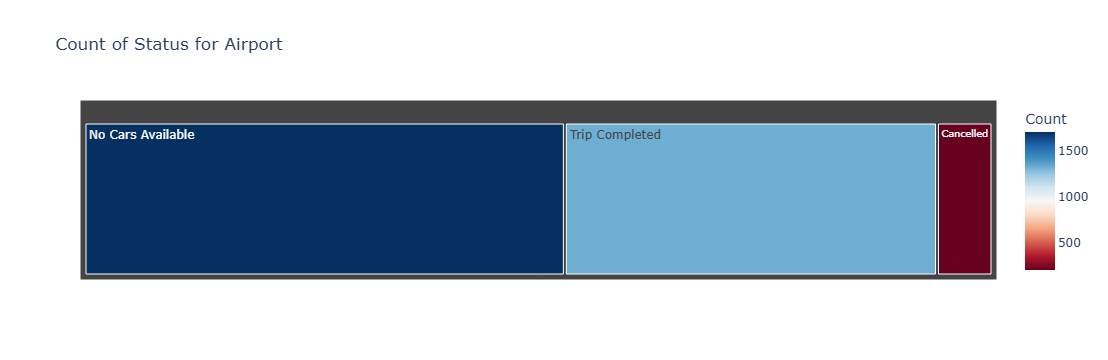

In [42]:
# Chart Visualization Codes
plt.style.use("dark_background")
md.columns = md.columns.str.strip()  # Removes the unnecessary spaces inside the columns
airport_df = md[md["Pickup point"].str.strip() == "Airport"] # Filtering out the unnecessary spaces for airport pickup point

# Group by status and count
type_count = airport_df["Status"].value_counts().reset_index()
type_count.columns = ["Status", "Count"]

# Create the treemap
fig = px.treemap(type_count,
                 path = ["Status"],
                 values = "Count",
                 title = "Count of Status for Airport",
                 color = "Count",
                 color_continuous_scale = "RdBu")
# Show the plot
fig.show()
                 

#### 1. Why did you pick the specific chart ?
The above tree map gives clear details when we hover over it and helps us to compare various variables in single tree map.

#### 2. What are the insights found from the chart ?
The following are the insights for the above tree map :

1. In airport, No Cars Available Status got the highest count with 1713 counts.
2. Then, Trip Completed Status got the second highest count with 1327 trip completion.
3. Cancelled Status got the lowest count with 198 cancellations.


#### 3.Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the airport pickup point has less available cars because of which customers are preferring other cab services, if company wants to reduce or eliminate the competition, then they have to allocate more cars at airport, so as to increase customers engagement and profits.

## Chart - 7

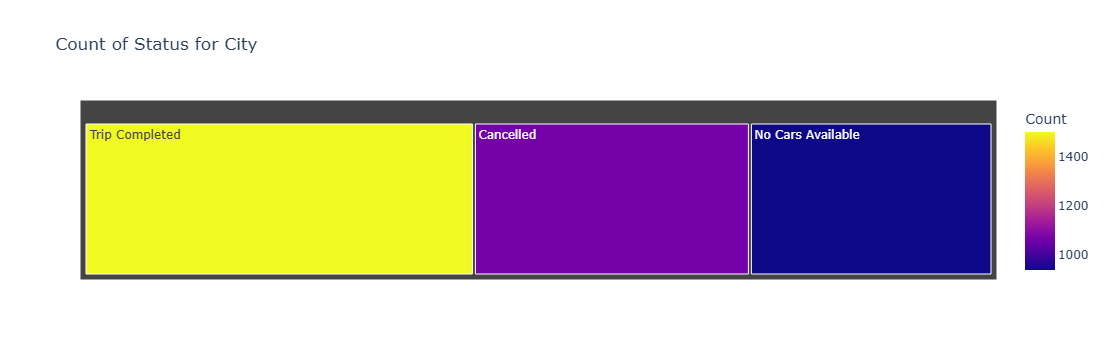

In [41]:
# Chart Visualization Codes
plt.style.use("dark_background")
md.columns = md.columns.str.strip()   # Remove unnecessary spaces inside the column
City_df = md[md["Pickup point"].str.strip() == "City"]  # Filtering out the unnecessary spaces for city pickup points

# Group by status and count
City_df_count = City_df["Status"].value_counts().reset_index()
City_df_count.columns = ["Status", "Count"]

# Create the tree map
fig = px.treemap(City_df_count,
                 path = ["Status"],
                 values = "Count",
                 title = "Count of Status for City",
                 color = "Count",
                 color_discrete_map = {"(?)" : "lightgrey", "Lunch" : "gold", "Dinner" : "darkblue"})

# Show the plot
fig.show()
                


#### 1. Why did you pick the specific chart ?
The above treemap gives clear details when we hover over it and helps us to compare various variables in single treemap.

#### 2. What are the insights found from the chart ?
The following are the insights for the above tree map :

1. In city, Trip Completed Status got the highest count with 1504 trip completions.
2. Then, Cancelled Status got the second highest count with 1066 cancellations.
3. No cars Available Status got the lowest count with 937 cars were not available during the trip request.

#### 3. Will the gained insights help creating positive business impact ?
Are there any insights that lead to negative growth ? justify with specific reason.

As we already know that the count for city pickup point is greater than airport and here we can see that the maximum count of cancelled trip is for city pickup point, which shows a bad impression that customer requests are not followed by drivers, this can ultimately reduce company rating, so as to avoid this, company should monitor on drivers who are cancelling rides inside city commute. So as to increase future customer engagement and overall company reputation.

## Chart - 8

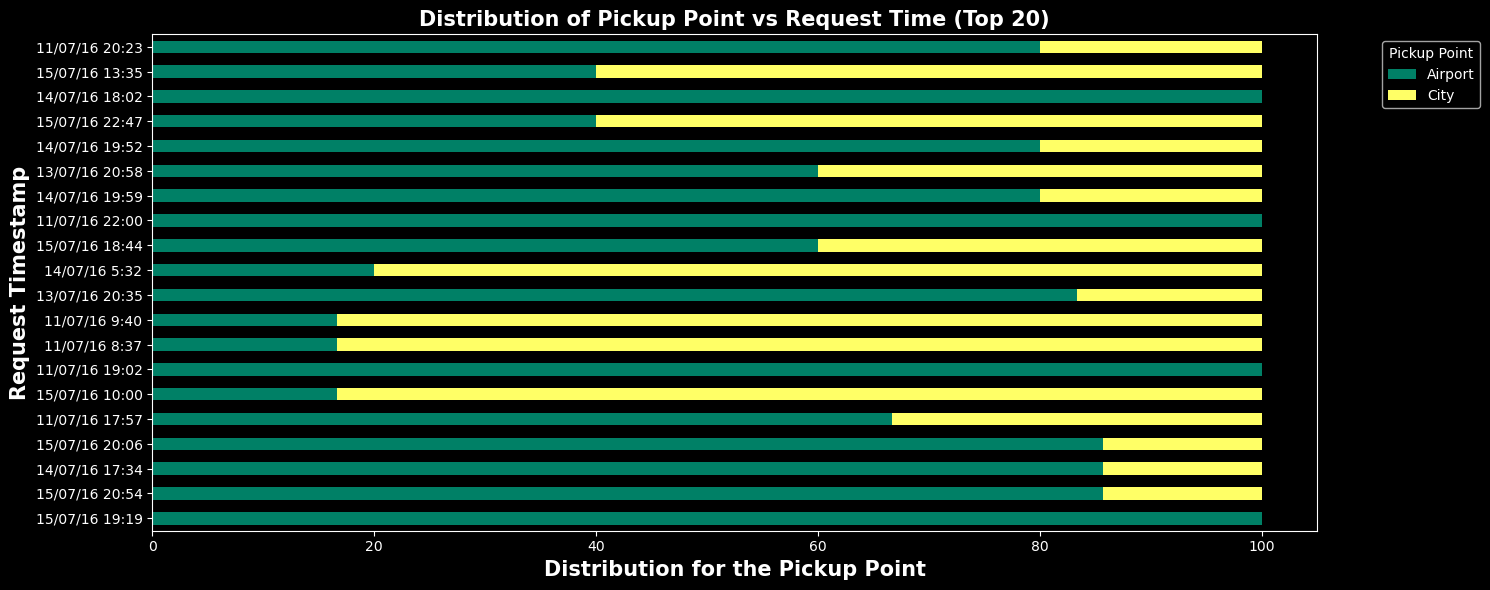

In [48]:
# Chart Visualization Codes
P_1 = md.groupby(["Request timestamp", "Pickup point"]).size().unstack(fill_value = 0)

# Normalize the data (percentage distribution)
P_11 = P_1.div(P_1.sum(axis = 1), axis = 0) * 100

# Select the top 20 stations by total trip count (sum of all user types per station)
top_P = P_1.sum(axis = 1).sort_values(ascending = False).head(20).index
P_top20 = P_11.loc[top_P]

# Plot stacked bar chart for top 20 stations
fig, ax = plt.subplots(figsize = (15,6))  # Adjust figure size
P_top20.plot(kind = "barh", stacked = True, colormap = "summer", ax = ax)

# Labels and titles
plt.xlabel("Distribution for the Pickup Point", fontweight = "bold", fontsize = 15)
plt.ylabel("Request Timestamp", fontweight = "bold", fontsize = 15)
plt.title("Distribution of Pickup Point vs Request Time (Top 20)", fontweight = "bold", fontsize = 15)
plt.legend(title = "Pickup Point",  bbox_to_anchor = (1.05,1), loc = "upper left")

plt.tight_layout()
plt.show()
                       


#### 1. Why did you pick the specific chart ?
The above stacked bar plot is great to visualize multi variable in distribution form for a variable

#### 2. What are the insights found from the chart ?
The following are the insights for the above stacked bar chart :

1. The highest distribution for airport pickup point is for the requst timestamp 19:02 and 22:00 on 11/07/16, 18:02 on 14/07/16, and 19:19 on 15/07/16.
2. The highest distribution for city pickup point is for the request timestamp 10:00 on 15/07/16, and 8:37 and 9:40 on 11/07/16.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the customers are preferring city commute mostly in the morning time and airport commute in the evening/night time.

## Chart - 9

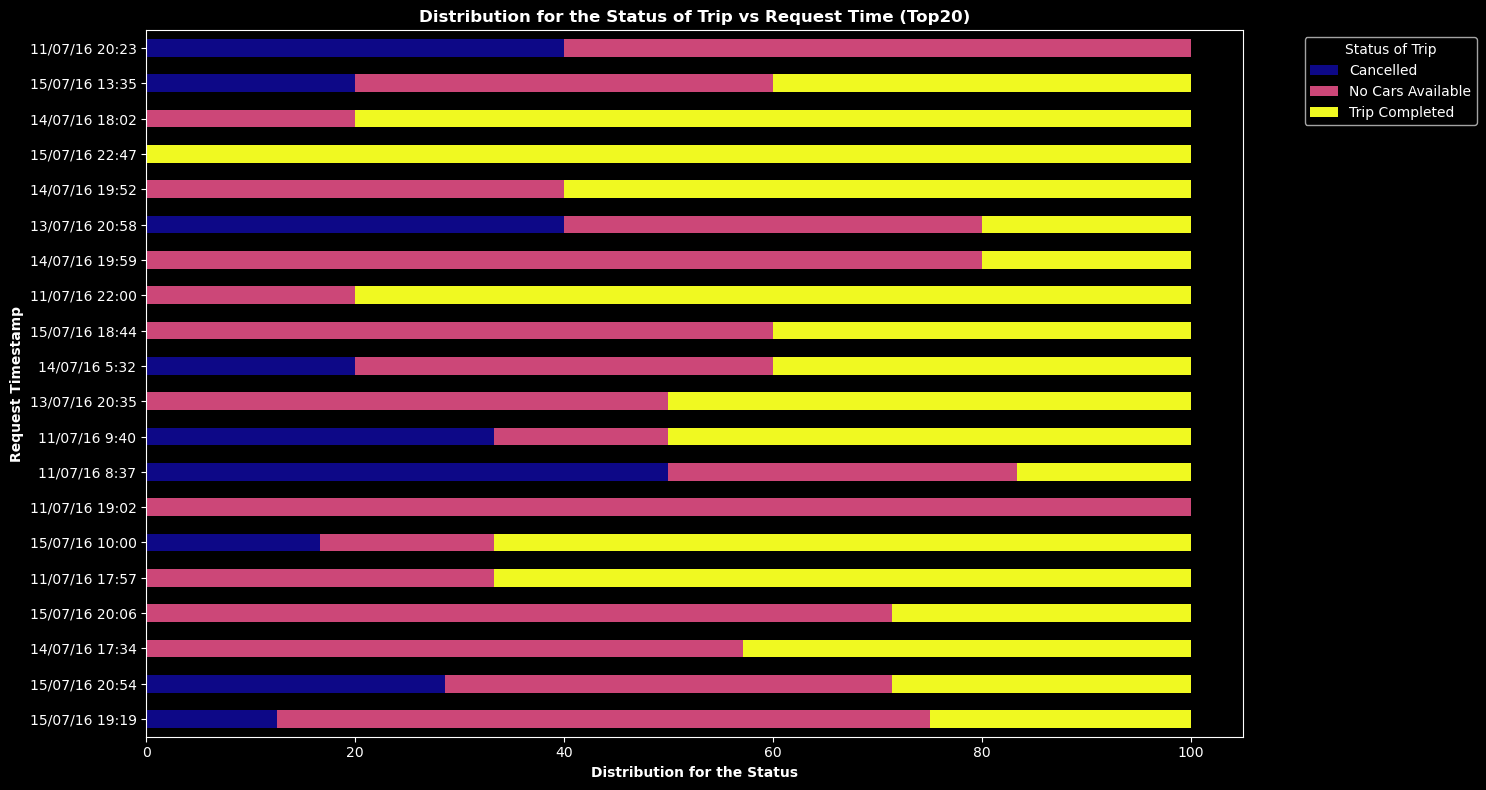

In [80]:
# Chart Visualization Codes
S_1 = md.groupby(["Request timestamp", "Status"]).size().unstack(fill_value = 0)

# Normalize the data (percentage distribution)
S_11 = S_1.div(S_1.sum(axis = 1), axis = 0) * 100

# Select top 20 stations by total trip count (sum of all user types per stations)
top_S = S_1.sum(axis = 1).sort_values(ascending = False).head(20).index
S_top20 = S_11.loc[top_S]

# plot stacked bar chart for top 20 stations
fig,ax = plt.subplots(figsize = (15,8))  # Adjust figure size
S_top20.plot(kind = "barh", stacked = True, colormap = "plasma", ax = ax)

# Labels and title
plt.xlabel("Distribution for the Status", fontweight = "bold")
plt.ylabel("Request Timestamp", fontweight = "bold")
plt.title("Distribution for the Status of Trip vs Request Time (Top20)", fontweight = "bold")
plt.legend(title = "Status of Trip", bbox_to_anchor = (1.05,1), loc = "upper left")

plt.tight_layout()
plt.show()


#### 1. Why did you pick the specific chart ?
The above stacked bar chart is great to visualize multi variable in distribution form for a variable.

#### 2. What are the insights found from the chart ?
The following are the insights for the above stacked bar chart :

1.  The highest count for No Cars Available status is for the request timestamp 19:02 on 11/07/16.
2.  The highest count for Cancelled status is for the request timestamp 8:37 on 11/07/16.
3.  The highest count for Trip Completed status is for the requset timestamp 22:47 on 15/07/16.   

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific answer.

The above insights shows that the no cars available status is mostly in evening/night time, cancelled status is mostly in morning time, and trip completed status is mostly in evening/night time. As per the morning time, drivers should be monitored constantly and they should be informed that to minimize the cancellation of cab service.

## Chart - 10

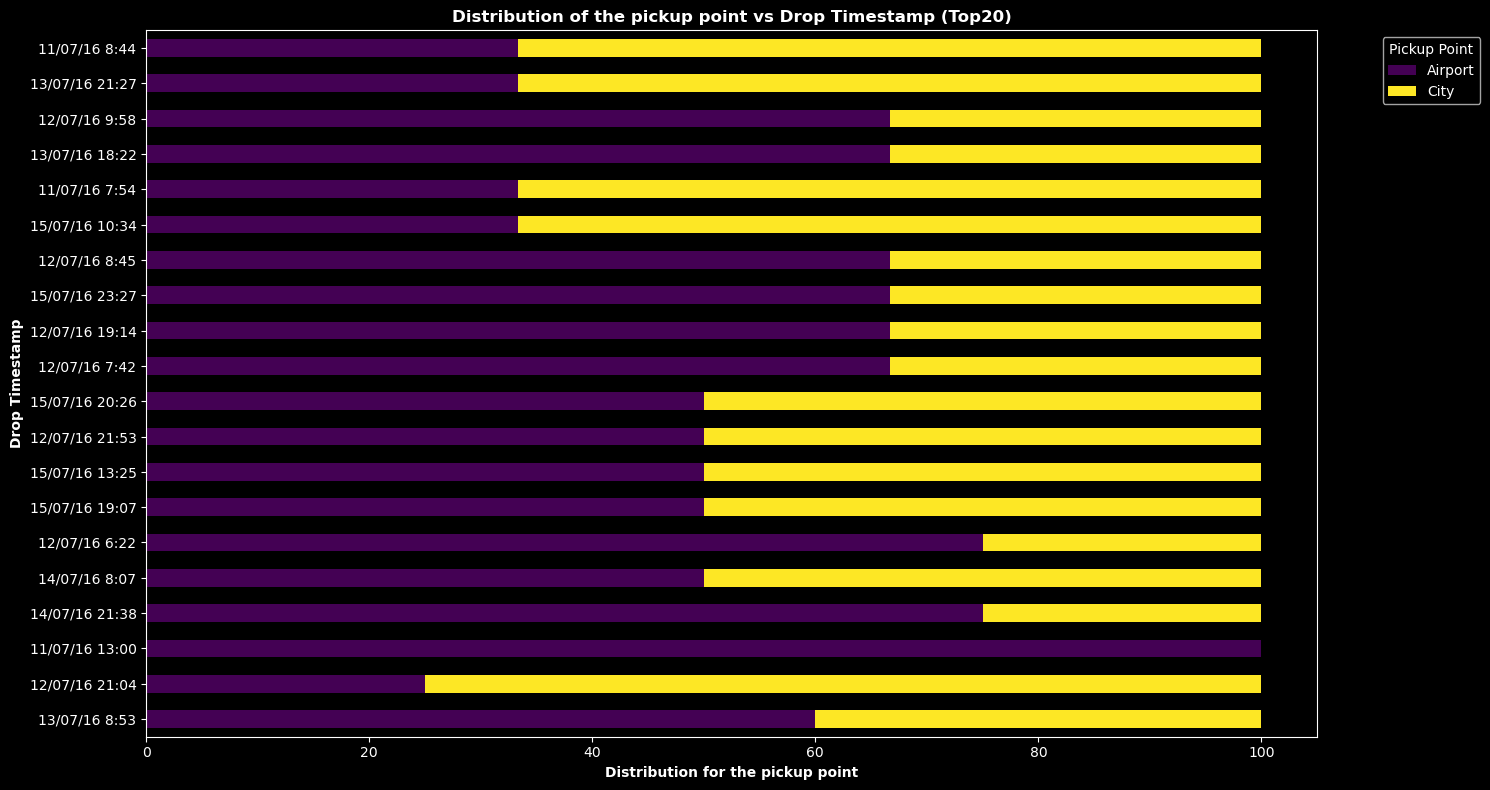

In [97]:
# Chart Visualization Codes
Pd_1 = md.groupby(["Drop timestamp", "Pickup point"]).size().unstack(fill_value = 0)

#Normalize the data (percentage distribution)
Pd_11 = Pd_1.div(Pd_1.sum(axis = 1), axis = 0) * 100

# Select top 20 stations by total trip count (sum of all user types per stations)
top_Pd = Pd_1.sum(axis = 1).sort_values(ascending = False).head(20).index
Pd_top20 = Pd_11.loc[top_Pd]


# Plot stacked bar chart for top 20 stations
fig,ax = plt.subplots(figsize = (15,8))   # Adjust figure size
Pd_top20.plot(kind = "barh", stacked = True, colormap = "viridis", ax = ax)


# Labels and title
plt.xlabel("Distribution for the pickup point", fontweight = "bold")
plt.ylabel("Drop Timestamp", fontweight = "bold")
plt.title("Distribution of the pickup point vs Drop Timestamp (Top20)", fontweight = "bold")
plt.legend(title = "Pickup Point", bbox_to_anchor = (1.05,1), loc = "upper left")

plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart ?
The above stacked bar chart is great to visualize multi variable in distribution form for a variable.

#### 2. What are the insights found from the chart ?
The following are the insights for the above stacked bar chart :

1.  The highest coun for the airport pickup point is for the drop timestamp 13:00 on 11/07/16, 6:22 on 12/07/16, and 21:38 on 14/07/16.
2.  The highest count for the city pickup point is for the drop timestamp 7:54 and 8:44 on 11/07/16, 21:04 on 12/07/16, and 10:34 on 15/07/16.  

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the airport and the city pickup point both have high count for morning and afternoon drop timestamp, which means customers are reaching their destination/arrivals in the morning/afternoon time.So, drivers should be informed that not to cancel morning/afternoon requests as it will impact company profits.

## Chart - 11

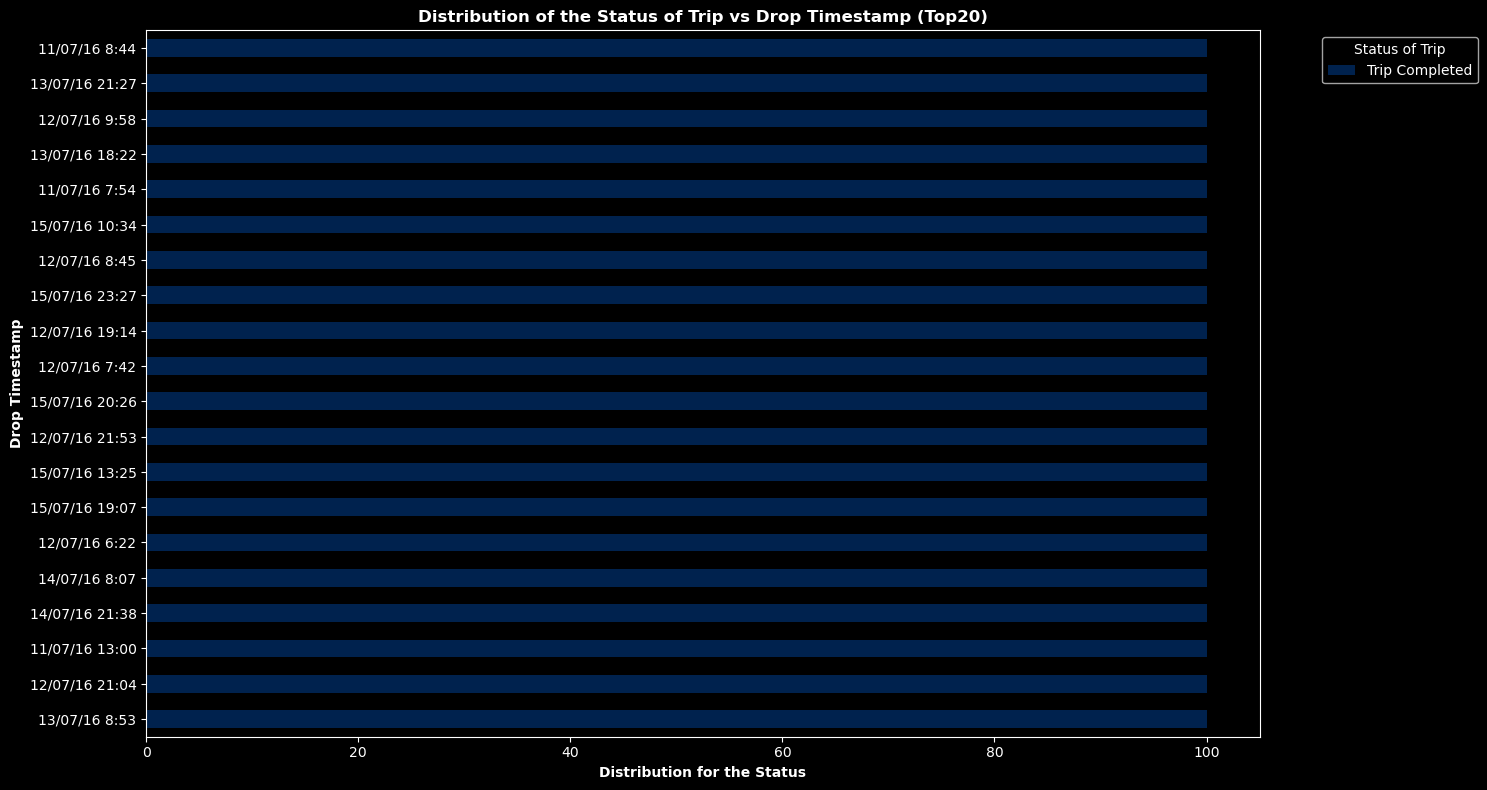

In [103]:
#  Chart Visualization Codes
Sd_1 = md.groupby(["Drop timestamp", "Status"]).size().unstack(fill_value = 0)

# Normalize the data (percentage distribution)
Sd_11 = Sd_1.div(Sd_1.sum(axis = 1), axis = 0) * 100

# Select top 20 stations by total trip count (sum of all user types per station)
top_Sd = Sd_1.sum(axis = 1).sort_values(ascending = False).head(20).index
Sd_top20 = Sd_11.loc[top_Sd]

# Plot stacked bar chart for top 50 stations
fig,ax = plt.subplots(figsize = (15,8))  # Adjust figure size
Sd_top20.plot(kind = "barh", stacked = True, colormap = "cividis", ax = ax)

# Labels and title
plt.xlabel("Distribution for the Status", fontweight = "bold")
plt.ylabel("Drop Timestamp", fontweight = "bold")
plt.title("Distribution of the Status of Trip vs Drop Timestamp (Top20)", fontweight = "bold")
plt.legend(title = "Status of Trip", bbox_to_anchor = (1.05,1), loc = "upper left")

plt.tight_layout()
plt.show()
          

#### 1. Why did you pick the specific chart ?
The above stacked bar chart is great to visualize multi variable in distribution form for a variable.

#### 2. what are the insights found from the chart ?
The above are the following insights for the above stacked bar chart :

1. The highest count for the Trip Completed status is for the drop timestamp 8:44, 7:54, and 13:00 on 11/07/16, 6:22, 7:42, 8:45, 9:58, 19:14, 21:04, and 21:53 on 12/07/16.
2. There are no count for Cancelled status and No Cars Available status.
                                                      
                                                      

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the drop time status is good mostly in the morning and at night, which means Cancelled status and No Cars Available staus are mostly done at afternoon and i the evening time. The company shoul inform drivers that, if they cancel trips in the morning and at night then they have to face penalty . As this will reduce cancellation and ultimately profits increase for the company. 

## Chart - 12

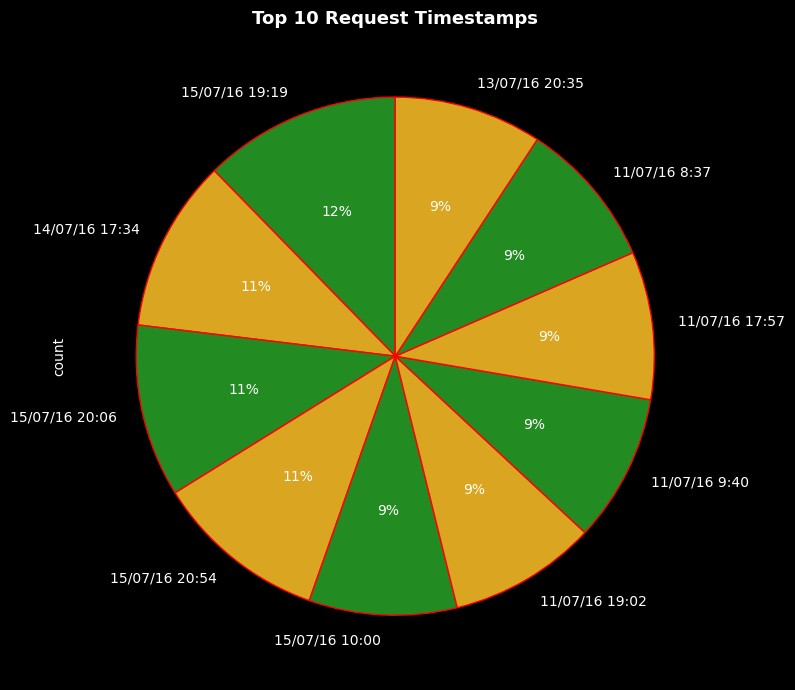

In [158]:
# Chart Visualization Codes
co = md["Request timestamp"].value_counts().head(10)

# No Conversion to int here
plt.figure(figsize = (15,7))
co.plot(
    kind = "pie",
    labels = co.index,  # keep as string
    autopct = lambda p :"{:.0f}%".format(p),
    colors = ["forestgreen", "goldenrod"],
    startangle = 90,
    wedgeprops = {"edgecolor" : "red"},
    textprops = {"fontsize" : 10, "color" : "white"}
 )

plt.title("Top 10 Request Timestamps", fontsize = 13, fontweight = "bold")
plt.tight_layout()
plt.show()


#### 1. why did you pick the specific chart ?
The above pie chart gives clear distribution of request timestamps and helps us to compare each of them with  each other easily.

#### 2. What are the insights found from the chart ?
the following are the insights for the above pie chart :

1. The highest distribution is for the request timestamp 19:19 on 15/07/16 with 12%.
2. The lowest distribution is for the request timestamps  8:37, 9:40, 17:57, and 19:02 on 11/07/16, 20:35 on 13/07/16, and 10:00 on 15/07/16 with 9% each.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the request time count is same for morning, evening, and night, but the request time count is nill at afternoon, to add profits to the organization, Uber should offer discounts to the customers, so that they also plan their journe at afternoon. 

## Chart - 13

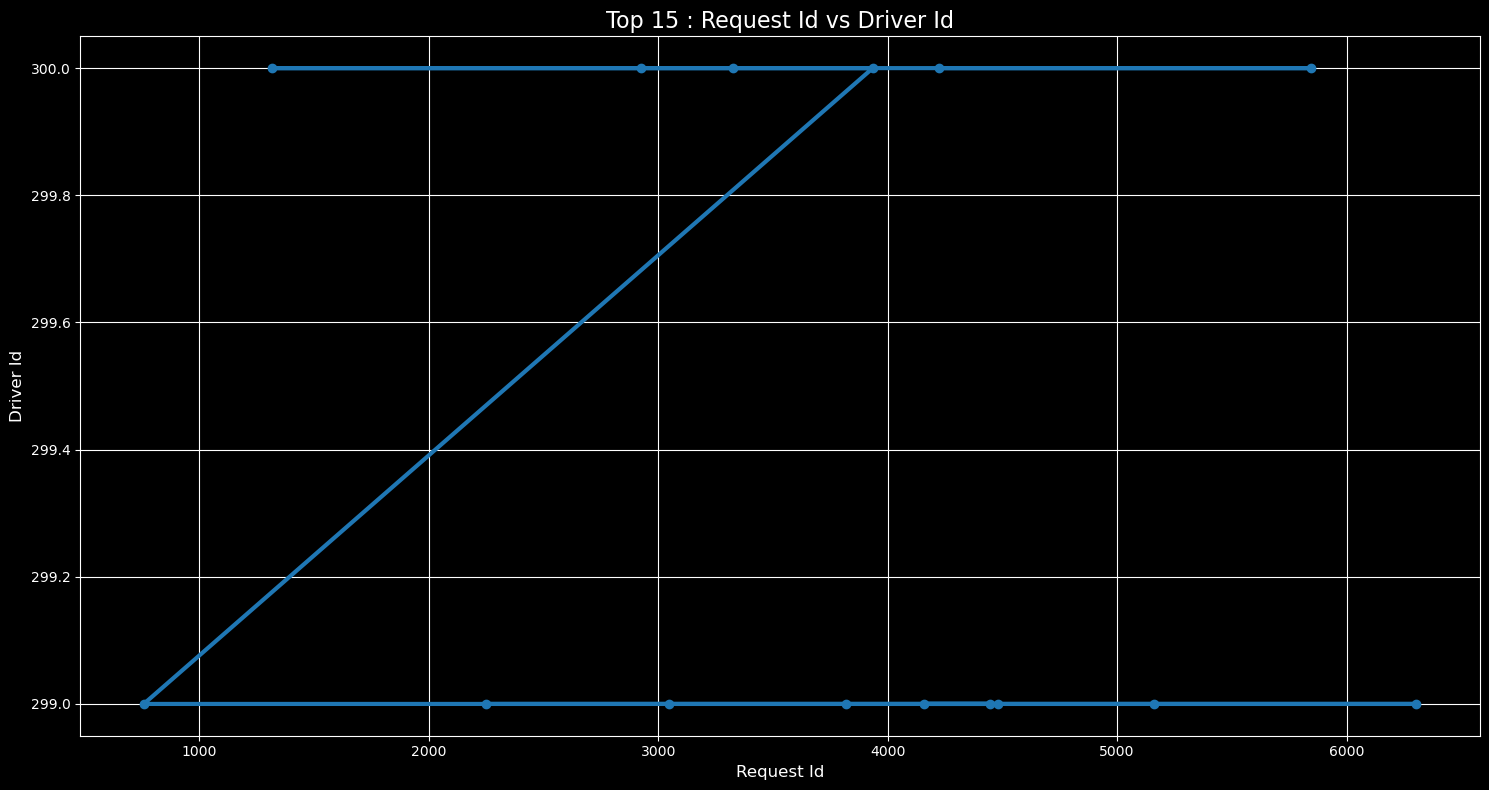

In [10]:
# Chart visualization Codes
plt.style.use("dark_background")

# Remove unnecessary spaces present in the column names
md.columns = md.columns.str.strip()

# Optional : Convert columns into numeric (in case they are string)
md["Driver id"] = pd.to_numeric(md["Driver id"], errors = "coerce")
md["Request id"] = pd.to_numeric(md["Request id"], errors = "coerce")

# Drop rows with missing values
md = md.dropna(subset = ["Driver id", "Request id"])

# Sorting top 15 Driver id in descending order
top_rd = md[["Request id", "Driver id"]].sort_values(by = "Driver id", ascending = False).head(15)

# Plotting graph
plt.figure(figsize = (15,8))
plt.plot(top_rd["Request id"], top_rd["Driver id"], marker = "o", color = "tab:blue", linestyle = "-", linewidth = 3)

plt.xlabel("Request Id", fontsize = 12)
plt.ylabel("Driver Id", fontsize = 12)
plt.title("Top 15 : Request Id vs Driver Id", fontsize = 16)
plt.grid(True)
plt.tight_layout()
plt.show()

#### 1. Why did you pick the specific chart ?
The above line chart is best for analyzing trends over a period of time for numerical variables.

#### 2. What are the insights found from the chart ?
The following are the insights for the above chart :

1. For the top 15 values, the above line chart shows a steady Z pattern over a specific of time.
2. Mostly the cab service requests are handled by Driver Id's 299 and 300.

#### 3. Will the gained insights help creating a positive business impact ?
Are there any insights that lead to negative growth ? Justify with specific reason.

The above insights shows that the driver Ids 299 and 300 are getting maximum business and also they are completing their business services successfully.

## Chart - 14

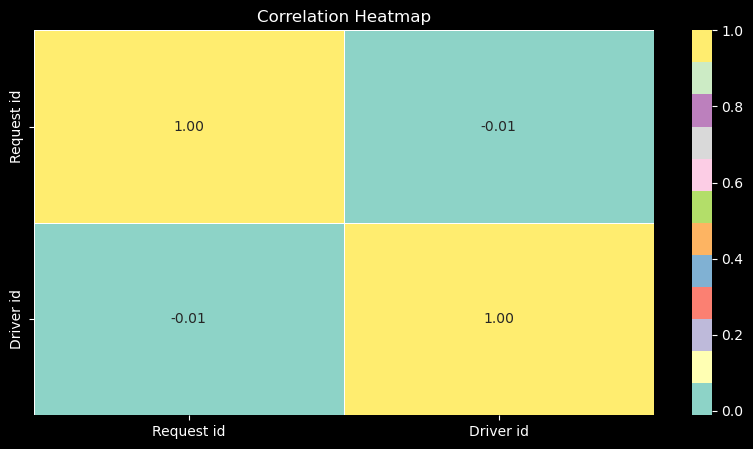

In [18]:
# Chart Visualization Codes
plt.style.use("dark_background")
numerical = md.select_dtypes(include = ["int64", "float64"])
corr_matrix = numerical.corr().fillna(0)

# Plotting the correlation heatmap
plt.figure(figsize = (10,5))
sns.heatmap(corr_matrix, annot = True, cmap = "Set3", fmt = ".2f", linewidth = 0.5)
plt.title("Correlation Heatmap")
plt.show()


#### 1. Why did you pick the specific chart ?
The above heatmap is good for analyzing the correlation between various numerical values with each other and itself.

#### 2. What is the insight found from the chart ?
The insight for above heatmap :

  From the heatmap, we can see that the correlation between Request ID and Driver ID is approximately zero (-0.01), indicating no relationship between them. This is expected because both are unique identifiers and do not carry analytical significance. This insight helps us understand that these variables are not useful for correlation analysis. Instead, we should focus on more meaningful insights

## Chart - 15

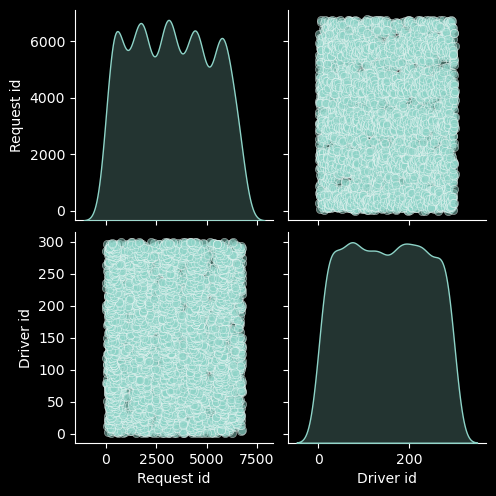

In [24]:
# Chart Visualization Codes
plt.style.use("dark_background")
numerical = md.select_dtypes(include = ["int64", "float64"])
numerical = numerical.dropna( axis = 1, thresh = len(numerical) * 0.8)
sns.pairplot(numerical, diag_kind = "kde", plot_kws = {"alpha" : 0.5})
plt.show()

#### 1. Why did you pick the specific chart ?
The pair plot is best for understanding the distribition and relation between two variables.

####2. What are the insights found from the chart ?
The following are the insights for above pair plot :

1. Request Ids are uniformily distributed.
2. Driver Ids are also uniformily distributed.
3. There is no visible correlation or pattern between them, The data is randomly spreaded, which is expected for ID columns, and they are not useful for analytical insights. 
